# Wikipedia Network Analysis: Hubs in Navigation Paths

In this notebook, we analyze the role of central nodes (hubs) in Wikispeedia navigation paths. We investigate:
- Most frequent nodes in actual challenges paths
- Correlation between node centrality and node frequency 
- Impact of hubs on navigation patterns

## Import Libraries and Load Data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from urllib.parse import unquote

In [14]:
# Load centrality measures
df_centrality = pd.read_csv('./data/mydata/centrality_measures.csv')

# Load challenge measures
df_challenges = pd.read_csv('./data/mydata/challenges_measures_final.csv')

# Load navigation paths
df_path_fin= pd.read_csv('./data/datasets/paths_finished.tsv', sep='\t', skiprows=16, names=['player','timestamp','duration','path','rating'])
df_path_fin["path"] = df_path_fin["path"].apply(lambda x: unquote(x))
df_path_unfin = pd.read_csv('./data/datasets/paths_unfinished.tsv', sep='\t', skiprows=17, names=['player','timestamp','duration','path', 'target', 'type'])
df_path_unfin["path"] = df_path_unfin["path"].apply(lambda x: unquote(x))


## Analysis of Navigation Paths

Let's analyze the most frequent nodes in actual navigation paths and see which nodes serve as bridges.

In [15]:
#extract nodes from navigation paths
def extract_nodes_from_paths(df, path_column):
    all_nodes = []
    for path in df[path_column].dropna():
        nodes = [node for node in str(path).split(';')[1:-1] if node != '<']  #Remove back clicks, source and target
        all_nodes.extend(nodes)
    return all_nodes

finished_path_nodes = extract_nodes_from_paths(df_path_fin, 'path')
unfinished_path_nodes = extract_nodes_from_paths(df_path_unfin, 'path')

#count nodes frequencies
all_nodes = finished_path_nodes + unfinished_path_nodes
total_nodes = len(all_nodes)
all_path_counts = Counter(all_nodes)

#print
print("Top 10 most frequent nodes in navigation paths:")
for i, (node, count) in enumerate(all_path_counts.most_common(10), 1):
    percentage = (count / total_nodes) * 100
    print(f"{i}. {node}: {count} appearances ({percentage:.2f}%)")

Top 10 most frequent nodes in navigation paths:
1. United_States: 11814 appearances (3.97%)
2. Europe: 5379 appearances (1.81%)
3. United_Kingdom: 5020 appearances (1.69%)
4. England: 4079 appearances (1.37%)
5. Earth: 4000 appearances (1.34%)
6. Africa: 3335 appearances (1.12%)
7. World_War_II: 2736 appearances (0.92%)
8. North_America: 2393 appearances (0.80%)
9. Animal: 2270 appearances (0.76%)
10. Human: 2222 appearances (0.75%)


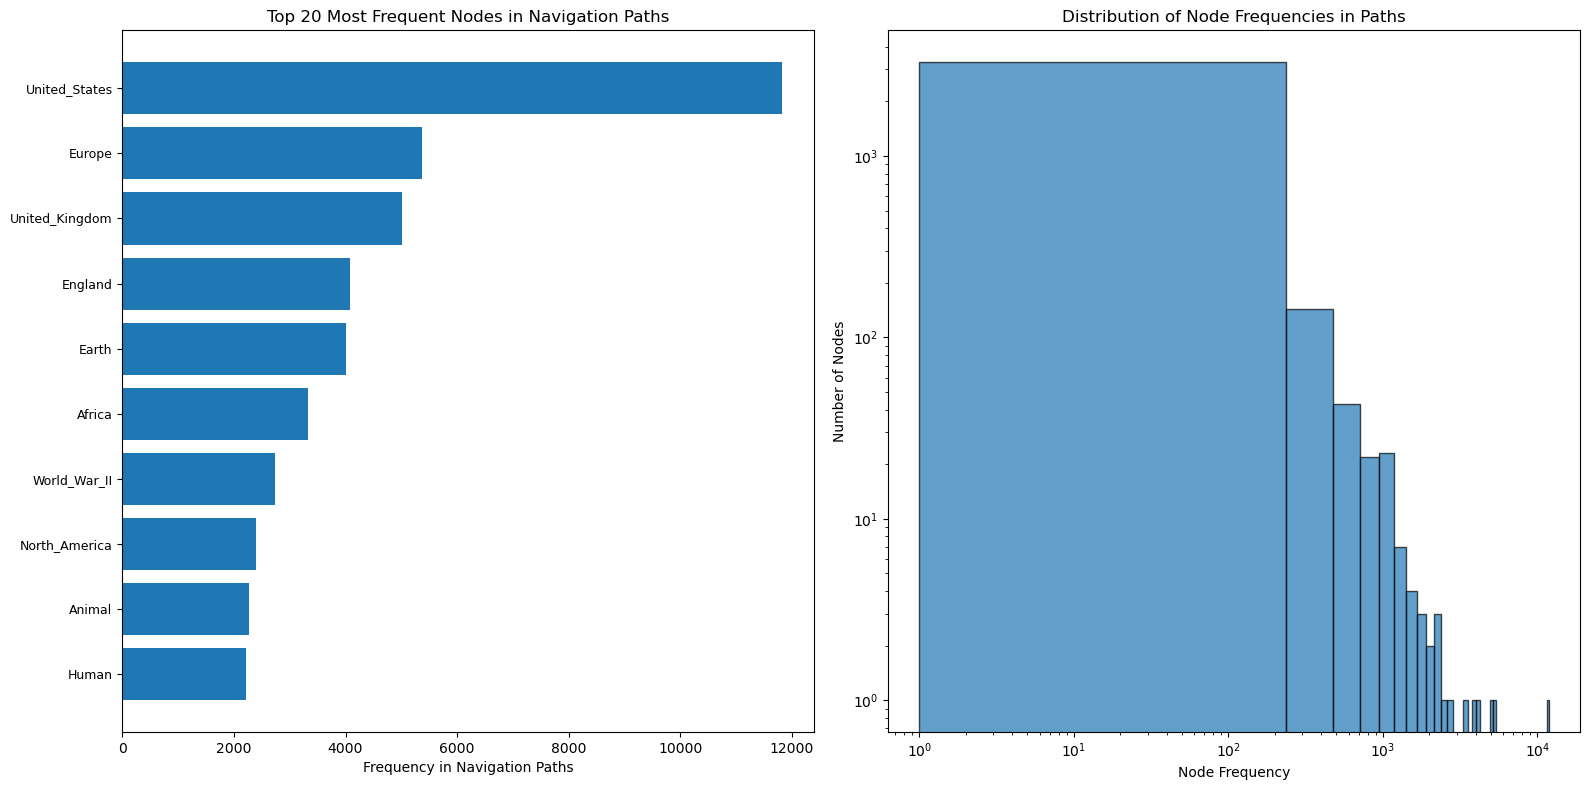

Most frequent node: United_States (11814 appearances)
Median frequency: 17.00
Mean frequency: 83.94


In [16]:
#plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#top 10 most frequent nodes
top_10_nodes = [node for node, _ in all_path_counts.most_common(10)]
top_10_counts = [count for _, count in all_path_counts.most_common(10)]

axes[0].barh(range(len(top_10_nodes)), top_10_counts)
axes[0].set_yticks(range(len(top_10_nodes)))
axes[0].set_yticklabels(top_10_nodes, fontsize=9)
axes[0].set_xlabel('Frequency in Navigation Paths')
axes[0].set_title('Top 20 Most Frequent Nodes in Navigation Paths')
axes[0].invert_yaxis()

#frequency distribution
all_frequencies = list(all_path_counts.values())
axes[1].hist(all_frequencies, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Node Frequency')
axes[1].set_ylabel('Number of Nodes')
axes[1].set_title('Distribution of Node Frequencies in Paths')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

#some statistics
print(f"Most frequent node: {all_path_counts.most_common(1)[0][0]} ({all_path_counts.most_common(1)[0][1]} appearances)")
print(f"Median frequency: {np.median(all_frequencies):.2f}")
print(f"Mean frequency: {np.mean(all_frequencies):.2f}")

### Results

We can observe that among the nodes most frequently visited by users, there are several nodes related to countries that we had already noticed to be highly central in the network according to various centrality measures. For example, we consistently see "United States" in the first position.
We can observe that the frequency distribution is incredibly unbalanced: the first position has approximately twice as many visits as the second, the vast majority of nodes have very low values, while the top nodes have much higher frequencie

## Centrality vs Node Frequency

Let's examine whether high-centrality nodes (hubs) are the ones most frequently used in navigation paths.

In [17]:
# Merge centrality data with node frequencies
path_freq_data = []
for node, freq in all_path_counts.items():
    path_freq_data.append({'node': node, 'frequency': freq})

df_path_freq = pd.DataFrame(path_freq_data)
df_merged = pd.merge(df_centrality, df_path_freq, on='node', how='inner')

# Calculate correlations between centrality measures and node frequency
centrality_cols = ['out_degree_centrality', 'in_degree_centrality', 'betweenness_centrality', 
                  'closeness_centrality', 'katz_centrality','frequency']

corr_matrix = df_merged[centrality_cols].corr()
print("\nCorrelations between centrality measures and frequency:")
print(corr_matrix["frequency"])

# Identify top hubs and check their node frequencies
top_dict = {}
last_dict = {}
for col in centrality_cols:
    top_nodes = df_merged.sort_values(col, ascending=False).head(10)['node'].reset_index(drop=True)
    top_dict[col] = top_nodes
   
top_table = pd.DataFrame(top_dict)
print("TOP hubs: ")
display(top_table)



Correlations between centrality measures and frequency:
out_degree_centrality     0.421873
in_degree_centrality      0.797014
betweenness_centrality    0.912706
closeness_centrality      0.411820
katz_centrality           0.719201
frequency                 1.000000
Name: frequency, dtype: float64
TOP hubs: 


,out_degree_centrality,in_degree_centrality,betweenness_centrality,closeness_centrality,katz_centrality,frequency
0,United_States,United_States,United_States,United_States,United_States,United_States
1,List_of_countries,United_Kingdom,United_Kingdom,Europe,France,Europe
2,List_of_circulating_currencies,France,England,United_Kingdom,United_Kingdom,United_Kingdom
3,List_of_sovereign_states,Europe,Europe,France,Europe,England
4,Africa,Germany,Africa,Germany,Germany,Earth
5,List_of_countries_by_system_of_government,England,Germany,World_War_II,World_War_II,Africa
6,Lebanon,World_War_II,19th_century,English_language,English_language,World_War_II
7,Interpol,India,World_War_II,India,India,North_America
8,Armenia,English_language,London,Latin,Spain,Animal
9,Georgia_(country),Japan,Earth,England,Russia,Human


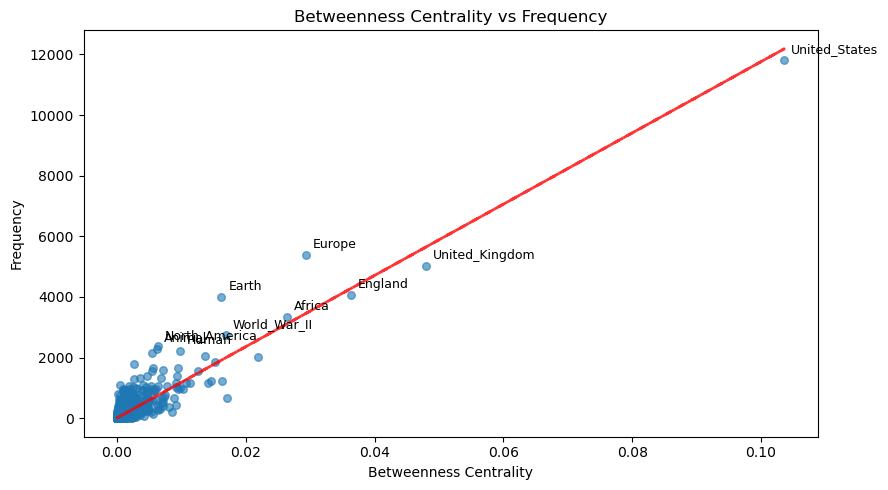

In [18]:
#plotting
fig, ax = plt.subplots(1, 1, figsize=(9, 5))


#scatterplot
ax.scatter(df_merged['betweenness_centrality'], df_merged['frequency'], alpha=0.6, s=30)
ax.set_xlabel('Betweenness Centrality')
ax.set_ylabel('Frequency')
ax.set_title(f'Betweenness Centrality vs Frequency')

#trend line
z = np.polyfit(df_merged['betweenness_centrality'], df_merged['frequency'], 1)
p = np.poly1d(z)
ax.plot(df_merged['betweenness_centrality'], p(df_merged['betweenness_centrality']), "r--", alpha=0.8, linewidth=2)

#annotates top 10
top_nodes = df_merged.nlargest(10, 'frequency')
for _, node in top_nodes.iterrows():
    ax.annotate(node['node'], 
                (node['betweenness_centrality'], node['frequency']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

## Results

We observe a positive correlation between frequency and all centrality measures, particularly with betweenness (over 90%). This suggests that bridge nodes, those traversed by a higher number of shortest paths, are also the most frequently visited by users during navigation.

This result is particularly interesting because, assuming that source-target pairs are selected randomly, users still tend to pass through bridge nodes more often. Regardless of their starting or ending points, the network structure itself encourages movement through these bridge nodes, which act as attractors.

Another interesting explanation is that some experienced users may have empirically discovered the strategic value of these nodes and begun to use them intentionally to complete their challenges more efficiently.


## Hubs and Path Difficulty Analysis

Let's analyze the relationship between the presence of high betweenness centrality nodes (hubs) in paths and path difficulty metrics.

In [22]:
# Get top 10 betweenness centrality nodes (hubs)
top_10_hubs = df_centrality.nlargest(10, 'betweenness_centrality')['node'].tolist()
print("Top 10 hubs (by betweenness centrality):")
for i, hub in enumerate(top_10_hubs, 1):
    print(f"{i}. {hub}")

# Function to check if a path contains any hub
def path_contains_hub(path, hubs):
    nodes_in_path = [node for node in str(path).split(';')[1:-1] if node != '<'] 
    return any(node in hubs for node in nodes_in_path)

# Analyze finished paths
df_path_fin['contains_hub'] = df_path_fin['path'].apply(lambda x: path_contains_hub(x, top_10_hubs))

paths_with_hubs = df_path_fin[df_path_fin['contains_hub'] == True]
paths_without_hubs = df_path_fin[df_path_fin['contains_hub'] == False]

Top 10 hubs (by betweenness centrality):
1. United_States
2. United_Kingdom
3. England
4. Europe
5. Africa
6. Germany
7. 19th_century
8. World_War_II
9. London
10. Earth


In [23]:
# Compare difficulty metrics between paths with and without hubs
avg_duration_with_hubs = paths_with_hubs['duration'].mean()
avg_duration_without_hubs = paths_without_hubs['duration'].mean()

avg_length_with_hubs = paths_with_hubs['path'].apply(lambda x: len(str(x).split(';')[1:-1])).mean()
avg_length_without_hubs = paths_without_hubs['path'].apply(lambda x: len(str(x).split(';')[1:-1])).mean()

avg_rating_with_hubs = paths_with_hubs['rating'].mean()
avg_rating_without_hubs = paths_without_hubs['rating'].mean()

print("Difficulty Comparison (Finished Paths):")
print(f"Average duration with hubs: {avg_duration_with_hubs:.2f} seconds")
print(f"Average duration without hubs: {avg_duration_without_hubs:.2f} seconds\n")

print(f"Average path length with hubs: {avg_length_with_hubs:.2f} nodes")
print(f"Average path length without hubs: {avg_length_without_hubs:.2f} nodes\n")

print(f"Average rating with hubs: {avg_rating_with_hubs:.2f}")
print(f"Average rating without hubs: {avg_rating_without_hubs:.2f}")

Difficulty Comparison (Finished Paths):
Average duration with hubs: 173.28 seconds
Average duration without hubs: 145.58 seconds

Average path length with hubs: 5.29 nodes
Average path length without hubs: 4.31 nodes

Average rating with hubs: 2.33
Average rating without hubs: 2.22


Surprisingly, the presence of a top-10 hub in the path does not appear to significantly affect any of the difficulty indicators (duration, length, rating). In fact, it seems make them sligthly worse.

In [24]:
# Compare finished vs unfinished paths hub usage
df_path_unfin['contains_hub'] = df_path_unfin['path'].apply(lambda x: path_contains_hub(x, top_10_hubs))

finished_with_hubs = df_path_fin['contains_hub'].sum()
finished_total = len(df_path_fin)
finished_hub_rate = finished_with_hubs / finished_total

unfinished_with_hubs = df_path_unfin['contains_hub'].sum()
unfinished_total = len(df_path_unfin)
unfinished_hub_rate = unfinished_with_hubs / unfinished_total

print("Hub usage comparison:")
print(f"Finished paths with hubs: {finished_with_hubs}/{finished_total} ({finished_hub_rate*100:.1f}%)")
print(f"Unfinished paths with hubs: {unfinished_with_hubs}/{unfinished_total} ({unfinished_hub_rate*100:.1f}%)")

Hub usage comparison:
Finished paths with hubs: 23517/51318 (45.8%)
Unfinished paths with hubs: 6582/24875 (26.5%)


We observe that the presence of at least one hub in a path is much more frequent in completed paths compared to incomplete ones. This could be due to the noisier and more unstable nature of data in incomplete paths. However, another possible explanation that requires further investigation is that once a player reaches a hub, completing the path becomes easier.

Perhaps more experienced players, who actively target hubs, are more likely to finish their challenges, while less experienced players, who do not adopt specific strategies, fail to reach the hubs, are unable to complete their paths, and eventually give up.

## Summary and Conclusions

This analysis of hubs (high-centrality nodes) in Wikipedia navigation paths revealed several important insights:

**1. Node Frequency Distribution**
- **United States** is the most frequently visited node in navigation paths, appearing in nearly 4% of all paths.
- **The frequency distribution is highly unbalanced:** while most nodes have very low frequencies, a small subset dominates user navigation behavior.

**2. Strong Correlation Between Centrality and Usage**

- **Betweenness centrality shows the strongest correlation (>90%) with node frequency**, indicating that bridge nodes attract user navigation or are strategically exploited by experienced players.
- **All centrality measures exhibit positive correlations with node frequency**, confirming that structural importance translates into actual usage.

**3. Hub Usage Patterns**

- **Finished paths contain hubs more often than unfinished paths**, suggesting that reaching a hub may facilitate path completion

This analysis confirms that the structural properties of the Wikipedia network influence human navigation behavior. Considering results from the previous notebook as well, we can conclude that **semantic relationships between articles play a minor role**. Instead, **structural features of the network are the main drivers** of user navigation patterns, either due to the natural attraction of bridge nodes or through intentional strategies used by experienced players.

Therefore, an effective strategy in the Wiki game may not involve constructing a semantically coherent path between source and target. Rather, it may rely on exploiting the most central nodes, such as **country** articles.
